In [51]:
# Used Car Price Prediction
# ==========================
# Supervised Learning Regression Project
#
# Objective:
# Predict the resale price of a used car using
# vehicle specifications, history and market information.

In [52]:
# Imports
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully!")

Libraries imported successfully!


In [53]:
# Loading Dataset
file_path = file_path = "C:/Users/arft/Downloads/Used_Car_Price_Regression_Dataset.xlsx"


cars = pd.read_excel(
    file_path,
    sheet_name="Car_Data"
)

cars.head()

,Car_ID,Brand_Tier,City_Market,Car_Age_Years,Mileage_KM,Engine_Size_CC,Horsepower_HP,Fuel_Type,Transmission,Previous_Owners,Accident_History,Service_History_Score,Price_USD
0,CAR00001,Mid-range,Sydney,4.30,71744,2740,225,Petrol,Automatic,0,No,5,17260
1,CAR00002,Luxury,New York,0.90,16708,1320,105,Petrol,Automatic,0,No,9,62520
2,CAR00003,Premium,New York,8.30,62956,1920,131,Hybrid,Automatic,1,No,9,25710
3,CAR00004,Mid-range,Islamabad,3.90,71148,1160,77,Petrol,Manual,2,No,5,4690
4,CAR00005,Economy,Dubai,0.80,3234,1810,146,Petrol,Manual,0,Yes,9,14390


In [54]:
print("Dataset Shape:", cars.shape)

print("\nColumns:")
print(cars.columns.tolist())

Dataset Shape: (2000, 13)

Columns:
['Car_ID', 'Brand_Tier', 'City_Market', 'Car_Age_Years', 'Mileage_KM', 'Engine_Size_CC', 'Horsepower_HP', 'Fuel_Type', 'Transmission', 'Previous_Owners', 'Accident_History', 'Service_History_Score', 'Price_USD']


In [55]:
#  Information
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Car_ID                 2000 non-null   object 
 1   Brand_Tier             2000 non-null   object 
 2   City_Market            2000 non-null   object 
 3   Car_Age_Years          2000 non-null   float64
 4   Mileage_KM             2000 non-null   int64  
 5   Engine_Size_CC         2000 non-null   int64  
 6   Horsepower_HP          2000 non-null   int64  
 7   Fuel_Type              2000 non-null   object 
 8   Transmission           2000 non-null   object 
 9   Previous_Owners        2000 non-null   int64  
 10  Accident_History       2000 non-null   object 
 11  Service_History_Score  2000 non-null   int64  
 12  Price_USD              2000 non-null   int64  
dtypes: float64(1), int64(6), object(6)
memory usage: 203.3+ KB


In [56]:
# Missing Values
missing = cars.isnull().sum()

missing_percentage = (
    cars.isnull().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing_Values": missing,
    "Missing_Percentage": missing_percentage
})

missing_summary

,Missing_Values,Missing_Percentage
Car_ID,0,0.00
Brand_Tier,0,0.00
City_Market,0,0.00
Car_Age_Years,0,0.00
Mileage_KM,0,0.00
Engine_Size_CC,0,0.00
Horsepower_HP,0,0.00
Fuel_Type,0,0.00
Transmission,0,0.00
Previous_Owners,0,0.00


In [57]:
# Duplicate Records
print(
    "Duplicate rows:",
    cars.duplicated().sum()
)

Duplicate rows: 0


In [58]:
# Unique Values
for column in cars.columns:
    print(f"\n{'='*50}")
    print(column)
    print("Unique values:", cars[column].nunique())

    if cars[column].nunique() <= 20:
        print(cars[column].unique())


Car_ID
Unique values: 2000

Brand_Tier
Unique values: 4
['Mid-range' 'Luxury' 'Premium' 'Economy']

City_Market
Unique values: 8
['Sydney' 'New York' 'Islamabad' 'Dubai' 'London' 'Toronto' 'Karachi'
 'Lahore']

Car_Age_Years
Unique values: 161

Mileage_KM
Unique values: 1924

Engine_Size_CC
Unique values: 222

Horsepower_HP
Unique values: 177

Fuel_Type
Unique values: 4
['Petrol' 'Hybrid' 'Diesel' 'Electric']

Transmission
Unique values: 2
['Automatic' 'Manual']

Previous_Owners
Unique values: 5
[0 1 2 3 4]

Accident_History
Unique values: 2
['No' 'Yes']

Service_History_Score
Unique values: 8
[ 5  9  8  3 10  7  4  6]

Price_USD
Unique values: 1447


In [59]:
# Descriptive Statistics
cars.describe().T

,count,mean,std,min,25%,50%,75%,max
Car_Age_Years,"2,000.00",3.89,3.66,0.10,1.20,2.70,5.43,18.00
Mileage_KM,"2,000.00","54,468.38","54,092.01",500.00,"16,237.25","36,316.50","75,269.25","260,000.00"
Engine_Size_CC,"2,000.00","1,800.23",481.59,800.00,"1,470.00","1,790.00","2,120.00","3,490.00"
Horsepower_HP,"2,000.00",135.76,38.68,60.00,108.00,134.00,162.00,262.00
Previous_Owners,"2,000.00",1.62,1.08,0.00,1.00,2.00,2.00,4.00
Service_History_Score,"2,000.00",6.55,2.29,3.00,5.00,7.00,9.00,10.00
Price_USD,"2,000.00","17,820.69","12,250.23","1,500.00","9,847.50","14,960.00","21,992.50","67,610.00"


In [60]:
# Categorical Statistics
cars.describe(include="object").T

,count,unique,top,freq
Car_ID,2000,2000,CAR00001,1
Brand_Tier,2000,4,Economy,705
City_Market,2000,8,Islamabad,284
Fuel_Type,2000,4,Petrol,1109
Transmission,2000,2,Automatic,1284
Accident_History,2000,2,No,1529


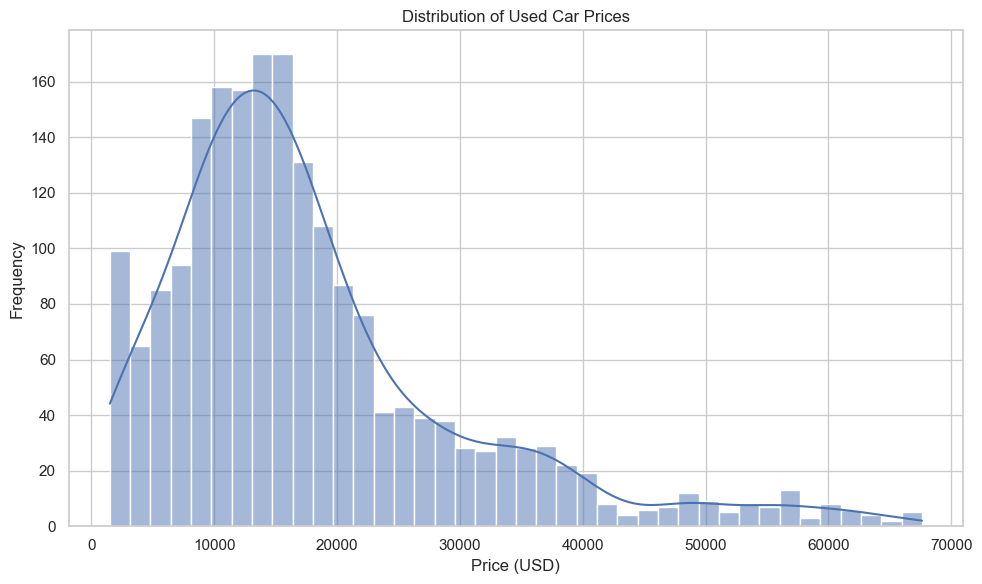

In [61]:
# Target Distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    cars["Price_USD"],
    bins=40,
    kde=True
)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

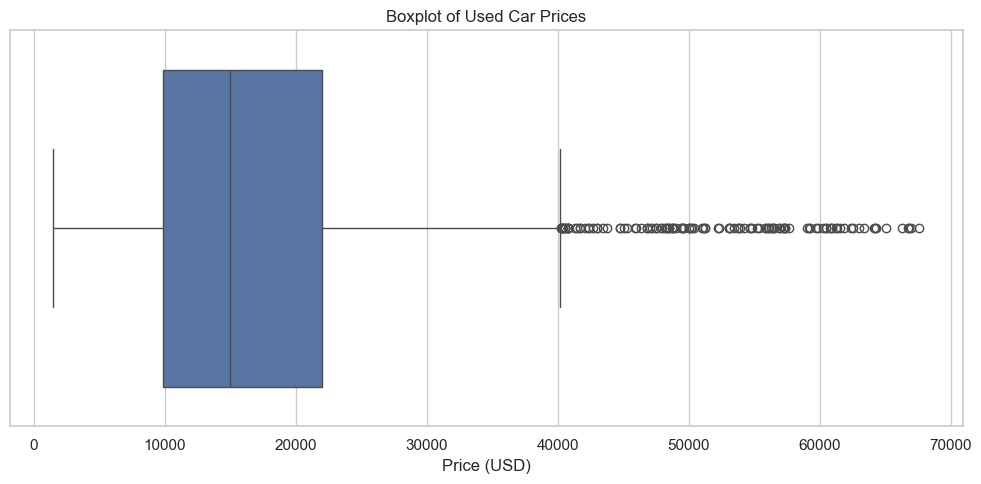

In [62]:
# Target Boxplot
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=cars["Price_USD"]
)

plt.title("Boxplot of Used Car Prices")
plt.xlabel("Price (USD)")

plt.tight_layout()
plt.show()

In [63]:
# Numerical Columns
numeric_columns = cars.select_dtypes(
    include=np.number
).columns.tolist()

numeric_columns

['Car_Age_Years',
 'Mileage_KM',
 'Engine_Size_CC',
 'Horsepower_HP',
 'Previous_Owners',
 'Service_History_Score',
 'Price_USD']

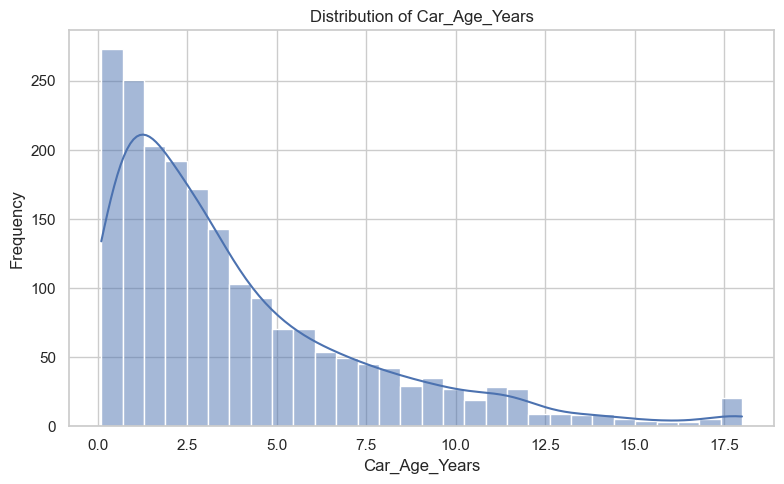

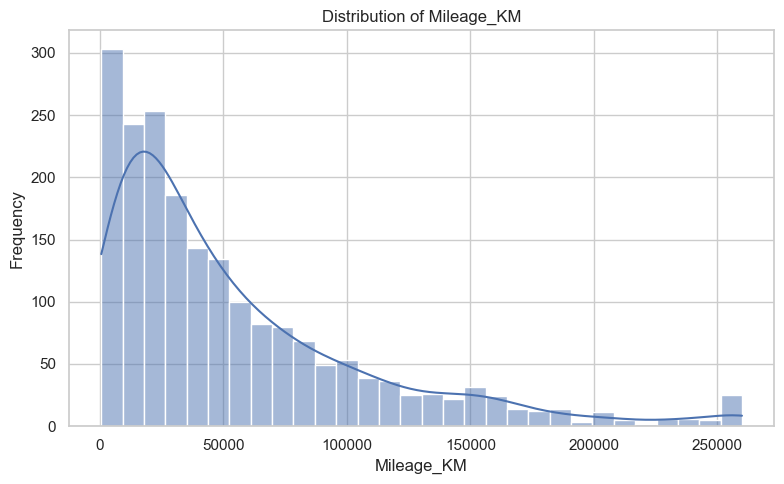

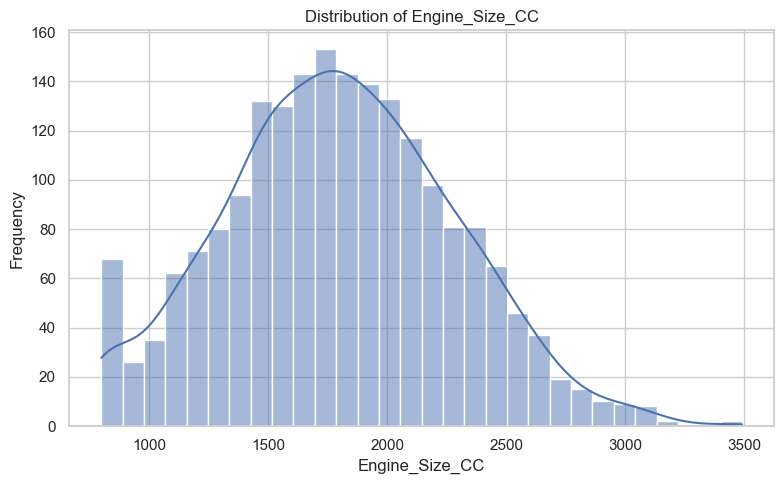

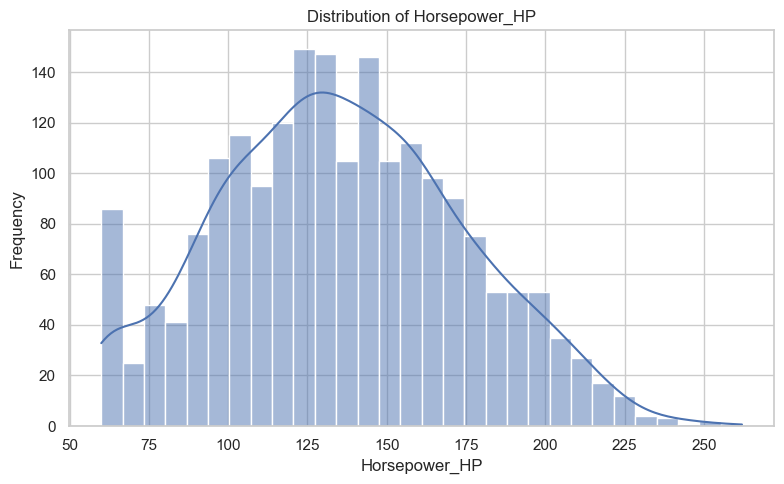

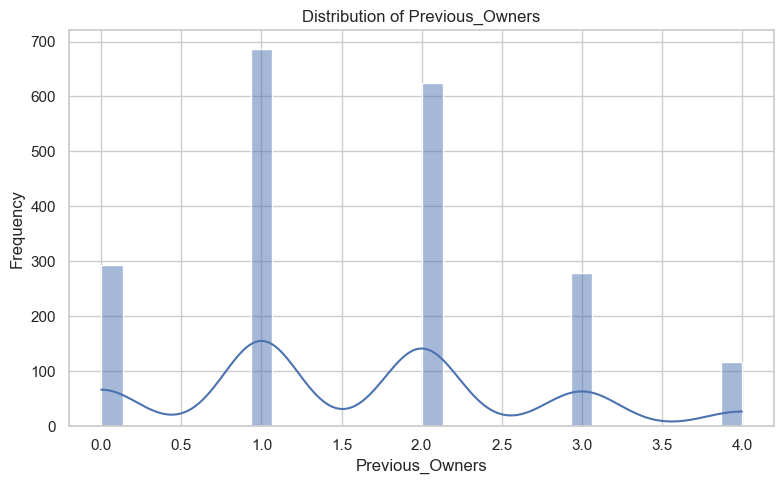

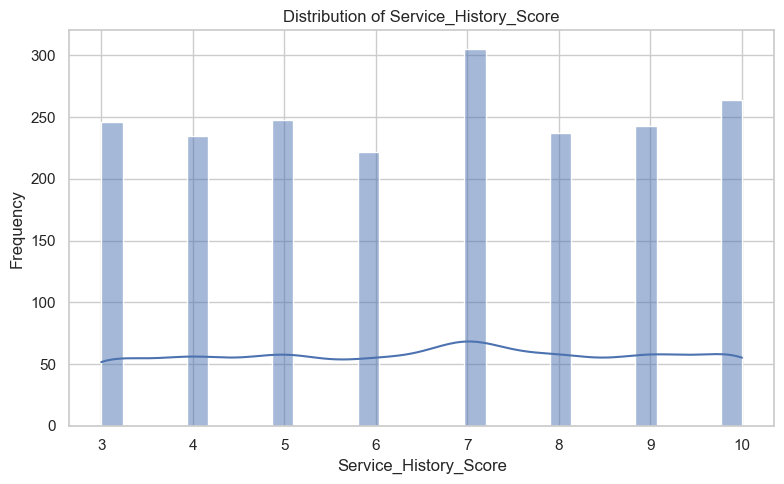

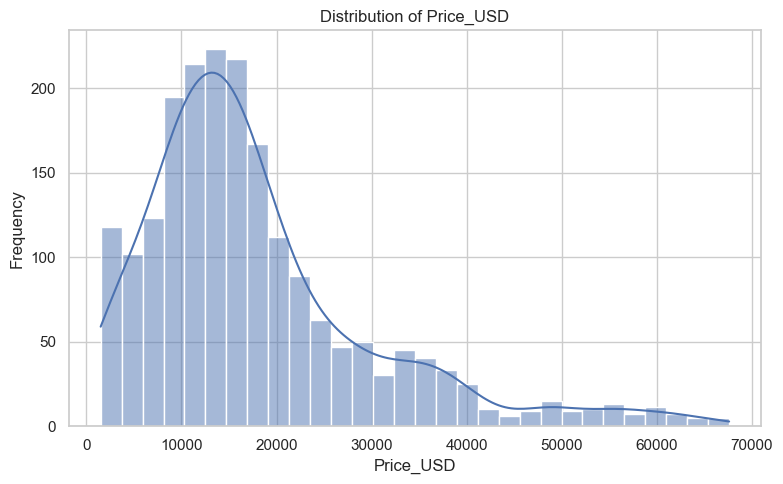

In [64]:
# Numerical Distributions
for column in numeric_columns:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        cars[column],
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

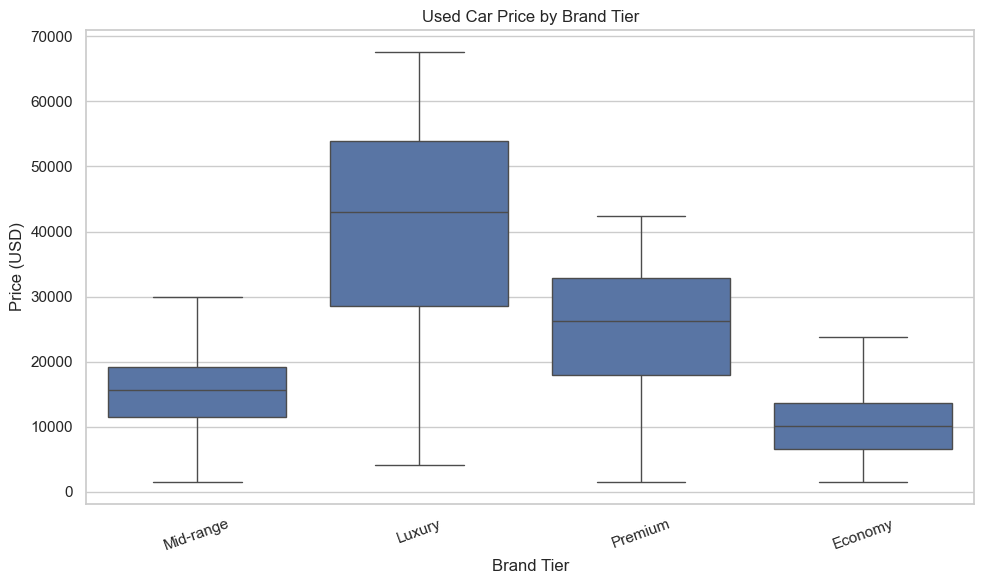

In [65]:
# Price by Brand Tier
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=cars,
    x="Brand_Tier",
    y="Price_USD"
)

plt.title("Used Car Price by Brand Tier")
plt.xlabel("Brand Tier")
plt.ylabel("Price (USD)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

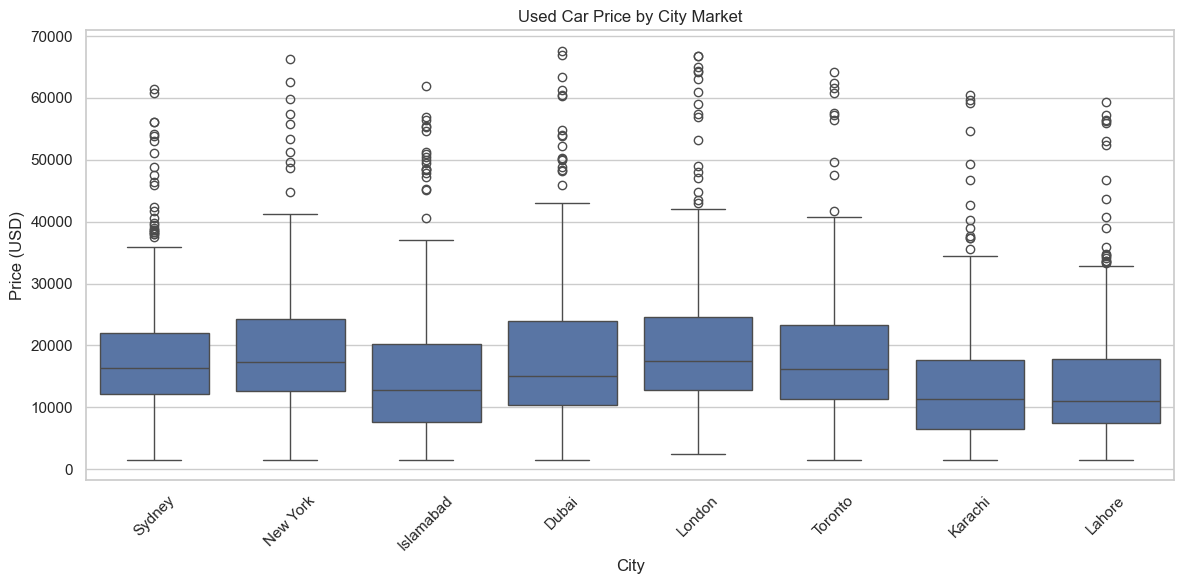

In [66]:
# Price by City
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=cars,
    x="City_Market",
    y="Price_USD"
)

plt.title("Used Car Price by City Market")
plt.xlabel("City")
plt.ylabel("Price (USD)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

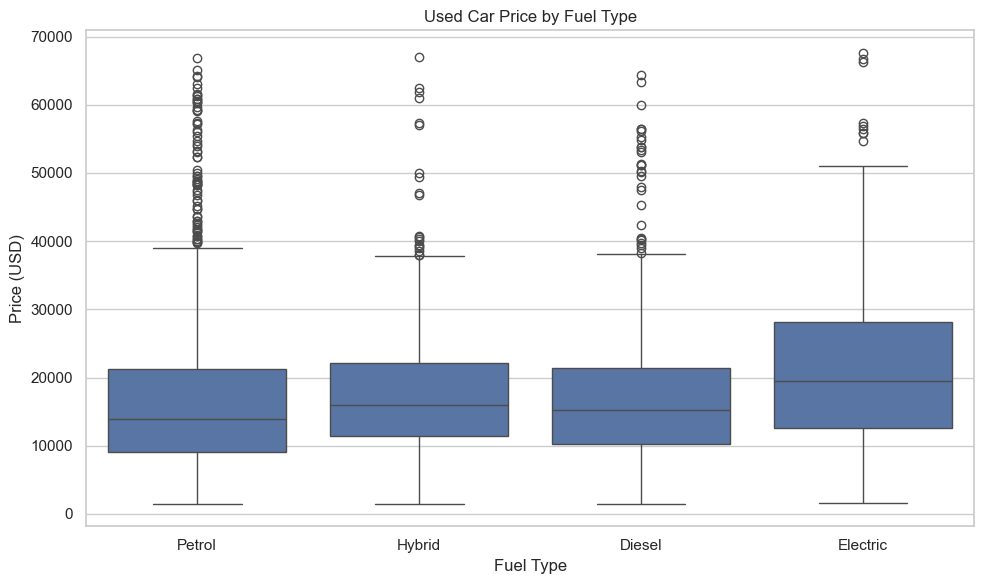

In [67]:
# Fuel Type
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=cars,
    x="Fuel_Type",
    y="Price_USD"
)

plt.title("Used Car Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price (USD)")

plt.tight_layout()
plt.show()

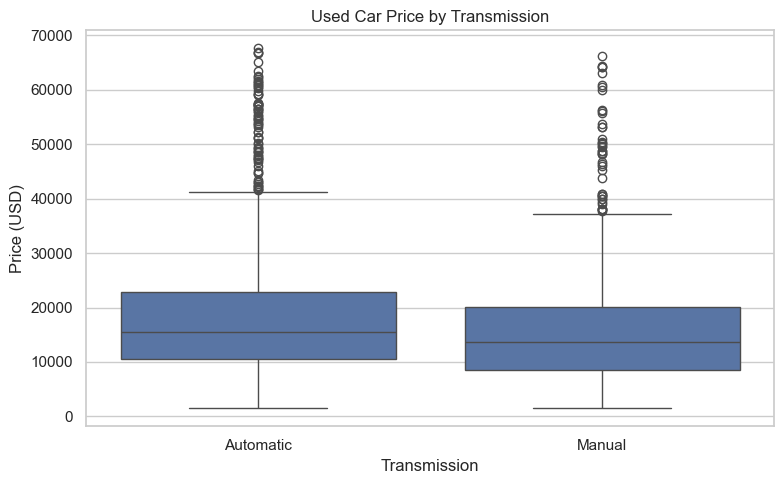

In [68]:
# Transmission 
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=cars,
    x="Transmission",
    y="Price_USD"
)

plt.title("Used Car Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Price (USD)")

plt.tight_layout()
plt.show()

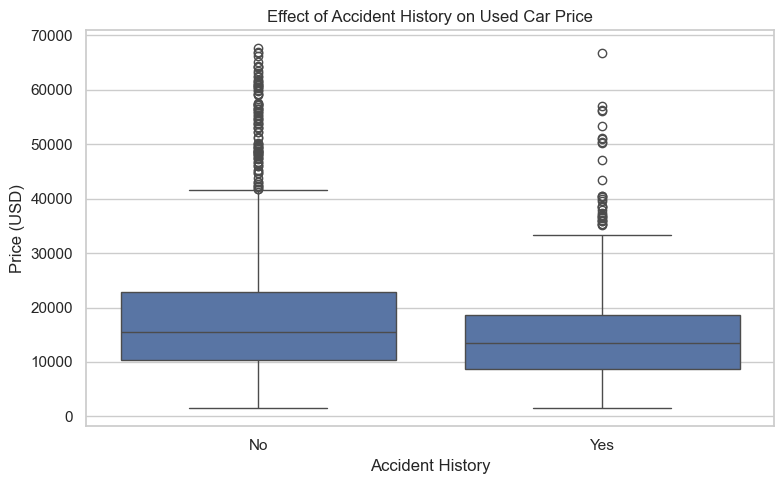

In [69]:
# Accident History
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=cars,
    x="Accident_History",
    y="Price_USD"
)

plt.title("Effect of Accident History on Used Car Price")
plt.xlabel("Accident History")
plt.ylabel("Price (USD)")

plt.tight_layout()
plt.show()

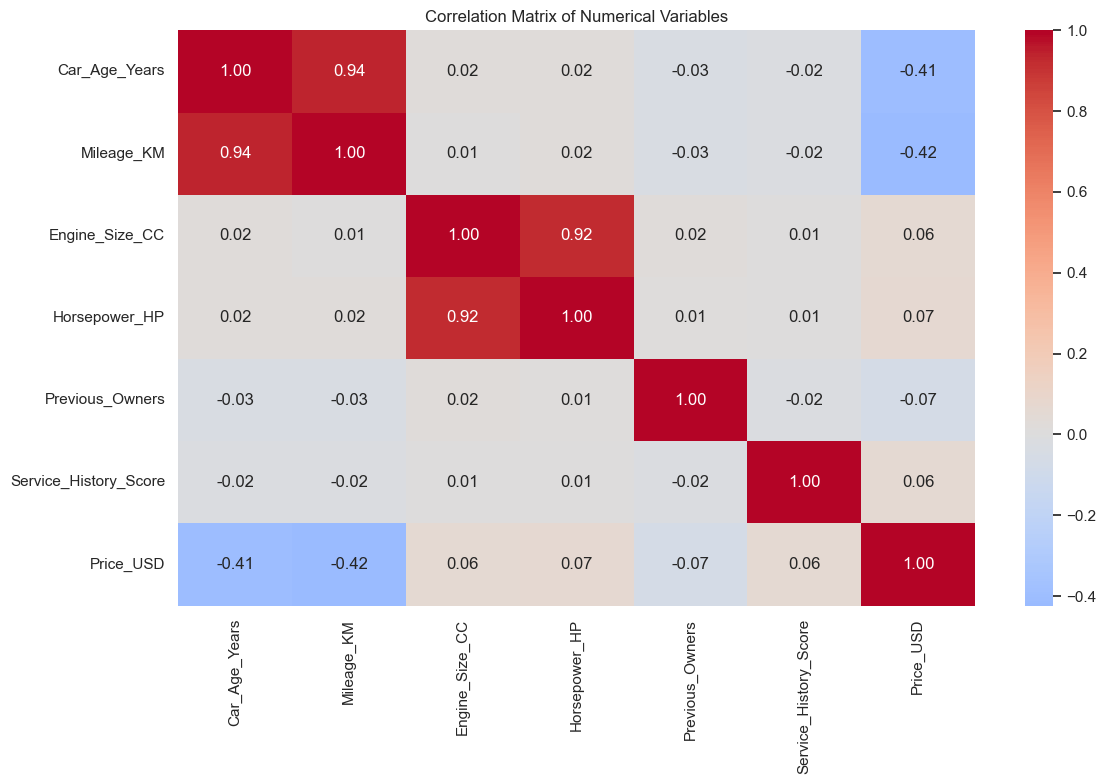

In [70]:
# Correlation Matrix
correlation_matrix = cars[
    numeric_columns
].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

In [71]:
# Correlation with Target
target_correlations = (
    cars[numeric_columns]
    .corr()["Price_USD"]
    .sort_values(ascending=False)
)

target_correlations

Price_USD                1.00
Horsepower_HP            0.07
Engine_Size_CC           0.06
Service_History_Score    0.06
Previous_Owners         -0.07
Car_Age_Years           -0.41
Mileage_KM              -0.42
Name: Price_USD, dtype: float64

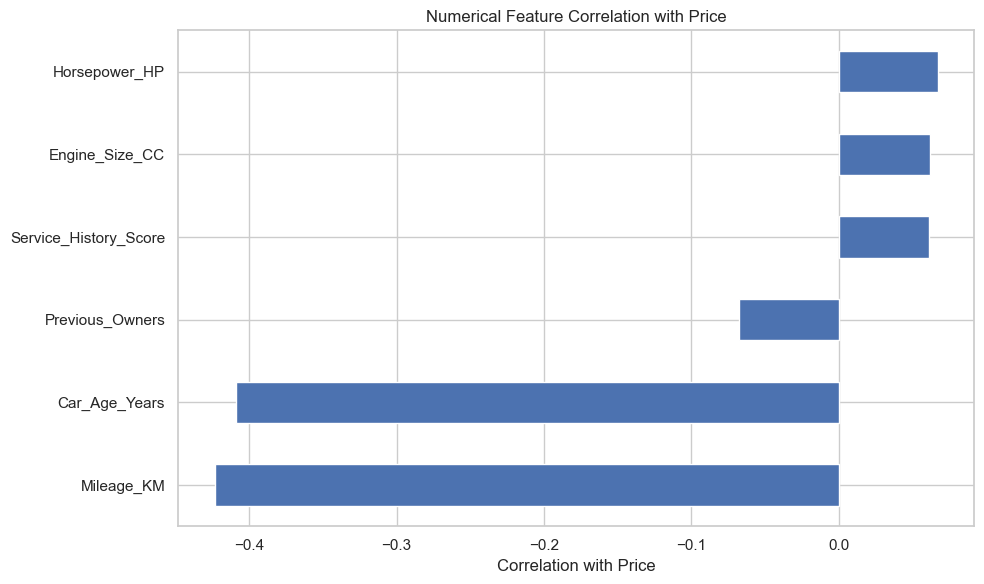

In [72]:
plt.figure(figsize=(10, 6))

target_correlations.drop("Price_USD").sort_values().plot(
    kind="barh"
)

plt.title("Numerical Feature Correlation with Price")
plt.xlabel("Correlation with Price")

plt.tight_layout()
plt.show()

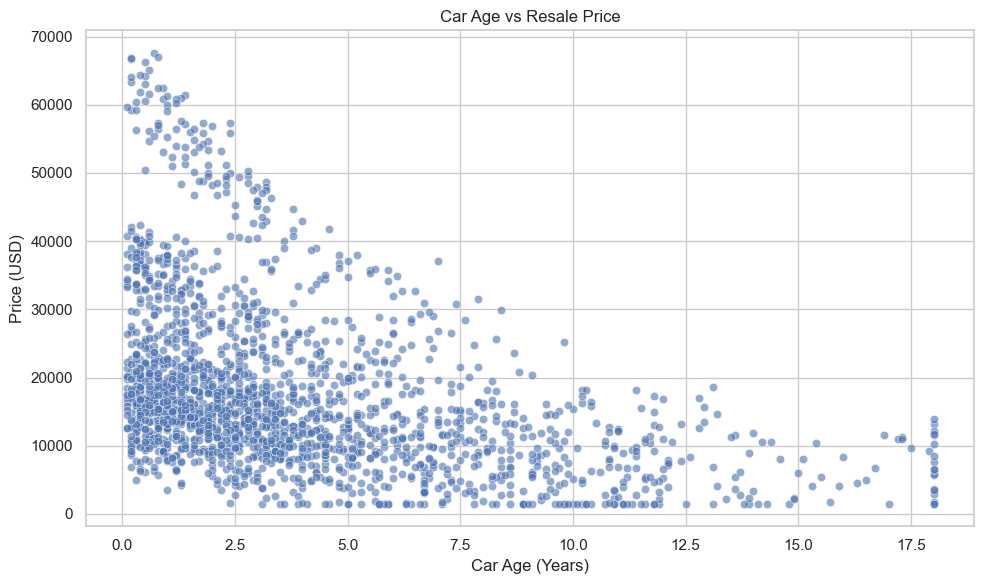

In [73]:
# Relationship Between Age and Price
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=cars,
    x="Car_Age_Years",
    y="Price_USD",
    alpha=0.6
)

plt.title("Car Age vs Resale Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Price (USD)")

plt.tight_layout()
plt.show()

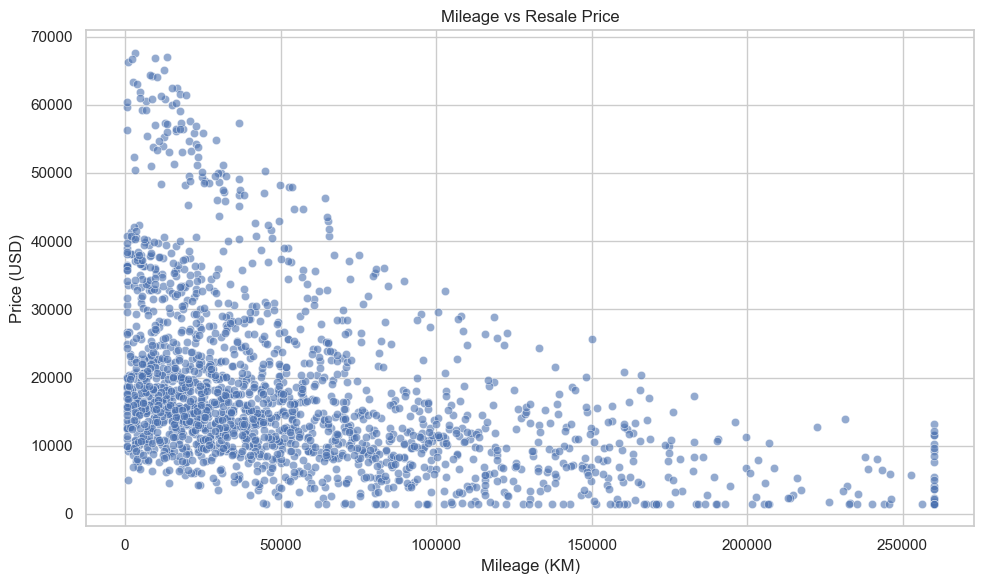

In [74]:
# Mileage vs Price
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=cars,
    x="Mileage_KM",
    y="Price_USD",
    alpha=0.6
)

plt.title("Mileage vs Resale Price")
plt.xlabel("Mileage (KM)")
plt.ylabel("Price (USD)")

plt.tight_layout()
plt.show()

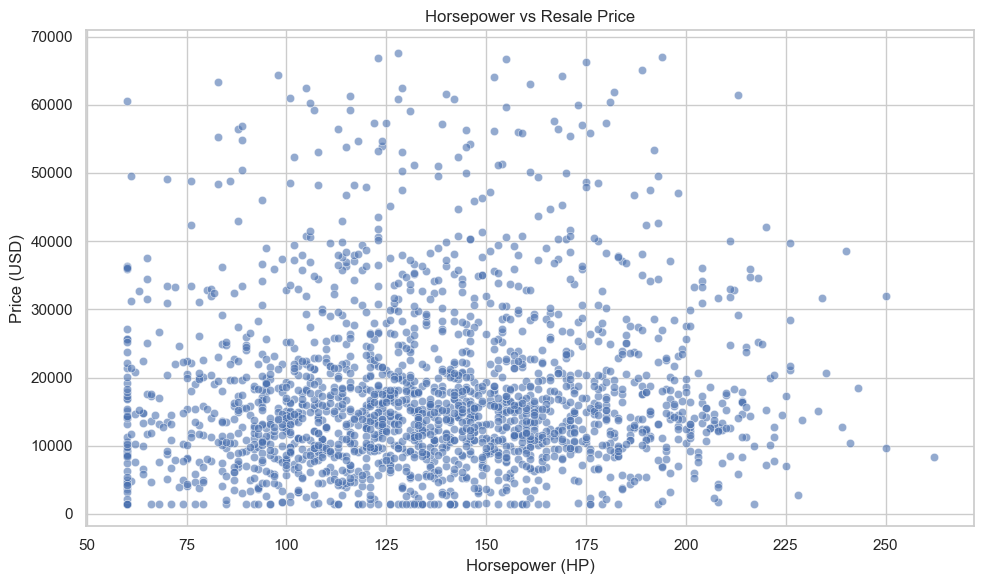

In [75]:
# Horsepower vs Price
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=cars,
    x="Horsepower_HP",
    y="Price_USD",
    alpha=0.6
)

plt.title("Horsepower vs Resale Price")
plt.xlabel("Horsepower (HP)")
plt.ylabel("Price (USD)")

plt.tight_layout()
plt.show()

In [76]:
# DATA PREPARATION

# Now we move from EDA → Machine Learning.

# Remove ID
cars_model = cars.drop(
    columns=["Car_ID"]
).copy()

print(cars_model.shape)

(2000, 12)


In [77]:
# Separate X and y
X = cars_model.drop(
    columns=["Price_USD"]
)

y = cars_model["Price_USD"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (2000, 11)
Target shape: (2000,)


In [78]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1600
Testing samples: 400


In [79]:
# Identify Feature Types
categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Brand_Tier', 'City_Market', 'Fuel_Type', 'Transmission', 'Accident_History']

Numerical features:
['Car_Age_Years', 'Mileage_KM', 'Engine_Size_CC', 'Horsepower_HP', 'Previous_Owners', 'Service_History_Score']


In [80]:
# Preprocessing Pipeline

# This is where the notebook becomes much more professional.

# Instead of manually encoding everything, i used a proper ColumnTransformer
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

preprocessor = ColumnTransformer([
    (
        "numerical",
        numeric_pipeline,
        numerical_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [81]:
# MODEL 1 — Linear Regression
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(X_test)

In [82]:
# MODEL 2 — Ridge Regression
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(
    X_train,
    y_train
)

ridge_predictions = ridge_model.predict(X_test)

In [83]:
# MODEL 3 — Lasso Regression
lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=100.0))
])

lasso_model.fit(
    X_train,
    y_train
)

lasso_predictions = lasso_model.predict(X_test)

In [84]:
# Decision Tree
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        DecisionTreeRegressor(
            max_depth=8,
            random_state=42
        )
    )
])

tree_model.fit(
    X_train,
    y_train
)

tree_predictions = tree_model.predict(X_test)

In [85]:
# MODEL 5 — Random Forest
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = random_forest_model.predict(X_test)

In [86]:
# MODEL 6 — Gradient Boosting
gradient_boosting_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    )
])

gradient_boosting_model.fit(
    X_train,
    y_train
)

gb_predictions = gradient_boosting_model.predict(X_test)

In [87]:
# MODEL COMPARISON
def evaluate_model(model_name, y_true, predictions):

    mae = mean_absolute_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )

    r2 = r2_score(
        y_true,
        predictions
    )

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

In [88]:
# Create Results Table
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)

results.append(
    evaluate_model(
        "Ridge Regression",
        y_test,
        ridge_predictions
    )
)

results.append(
    evaluate_model(
        "Lasso Regression",
        y_test,
        lasso_predictions
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        tree_predictions
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_predictions
    )
)

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

,Model,MAE,RMSE,R²
0,Gradient Boosting,"1,313.39","1,661.91",0.98
1,Random Forest,"1,900.32","2,505.37",0.96
2,Decision Tree,"2,661.38","3,495.51",0.93
3,Linear Regression,"2,719.12","4,163.21",0.90
4,Ridge Regression,"2,730.53","4,169.88",0.90
5,Lasso Regression,"2,963.10","4,334.52",0.89


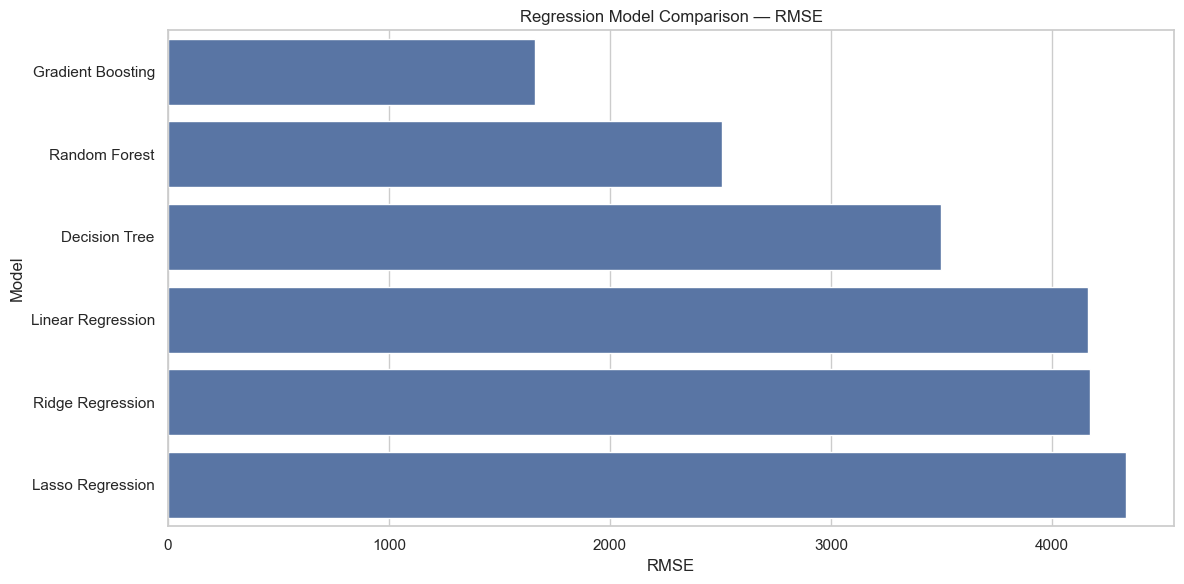

In [89]:
# Visual Model Comparison
results_plot = results_df.sort_values(
    "RMSE",
    ascending=True
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_plot,
    x="RMSE",
    y="Model"
)

plt.title("Regression Model Comparison — RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

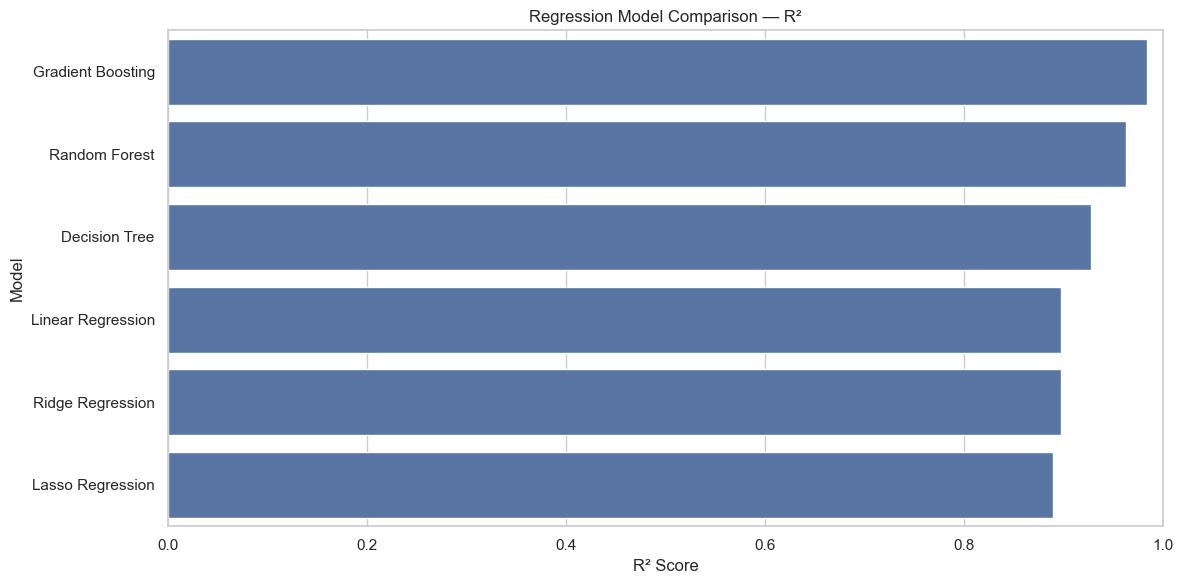

In [90]:
# R² Comparison
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df.sort_values(
        "R²",
        ascending=False
    ),
    x="R²",
    y="Model"
)

plt.title("Regression Model Comparison — R²")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

In [91]:
# ACTUAL VS PREDICTED
model_predictions = {
    "Linear Regression": linear_predictions,
    "Ridge Regression": ridge_predictions,
    "Lasso Regression": lasso_predictions,
    "Decision Tree": tree_predictions,
    "Random Forest": rf_predictions,
    "Gradient Boosting": gb_predictions
}

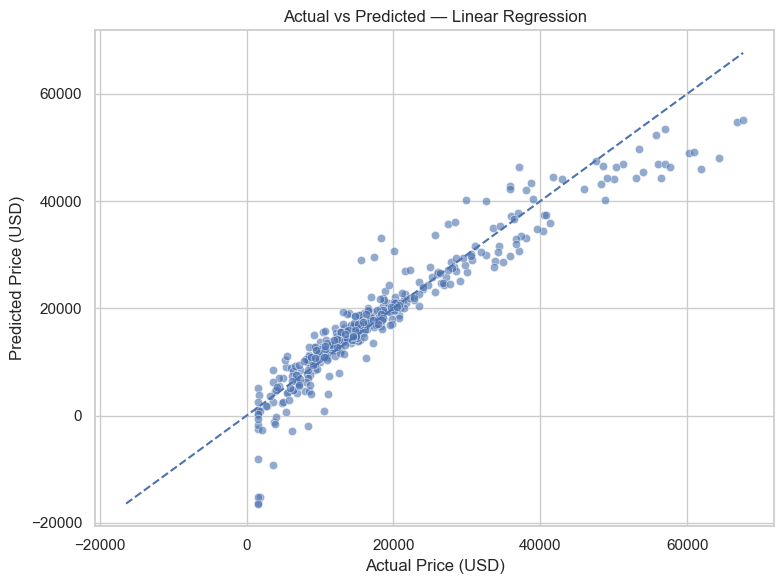

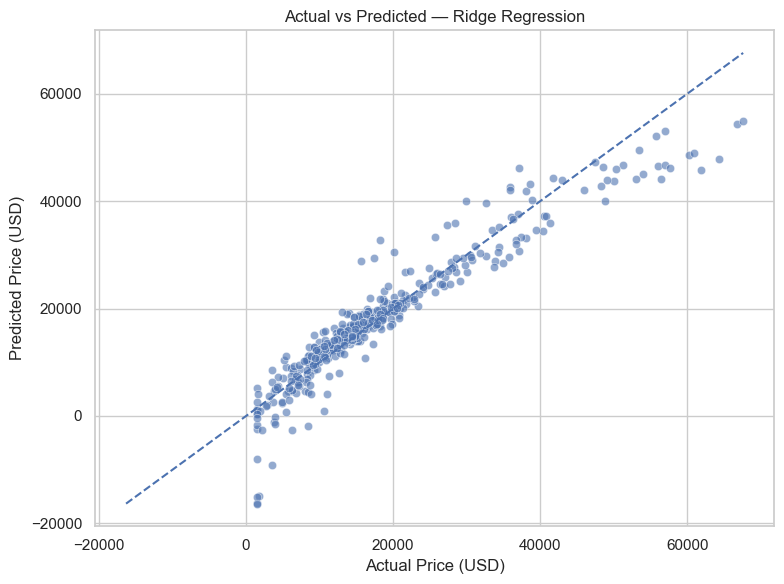

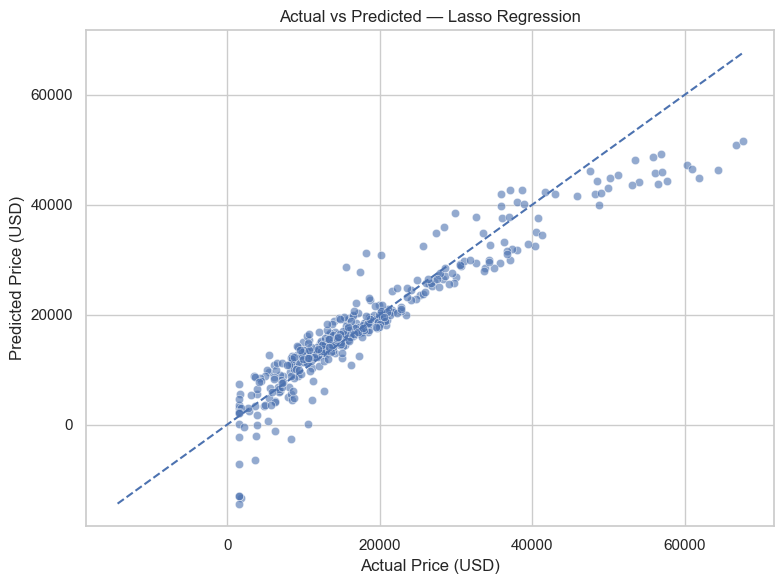

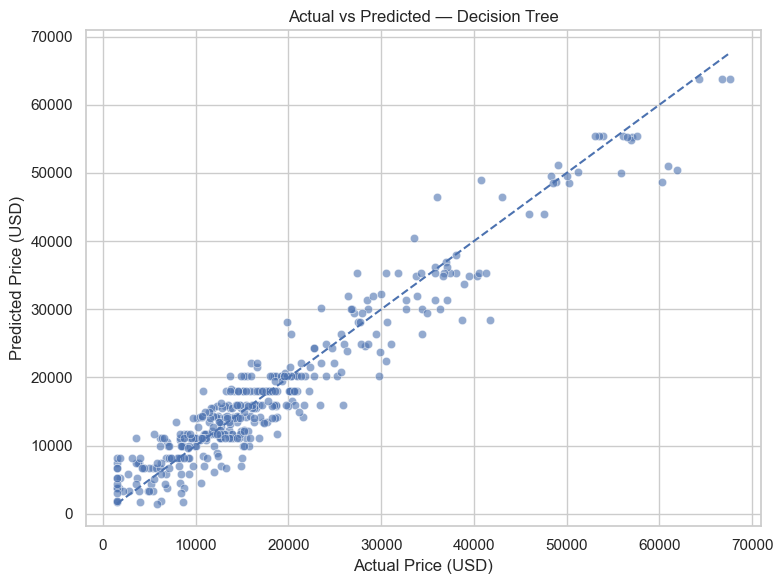

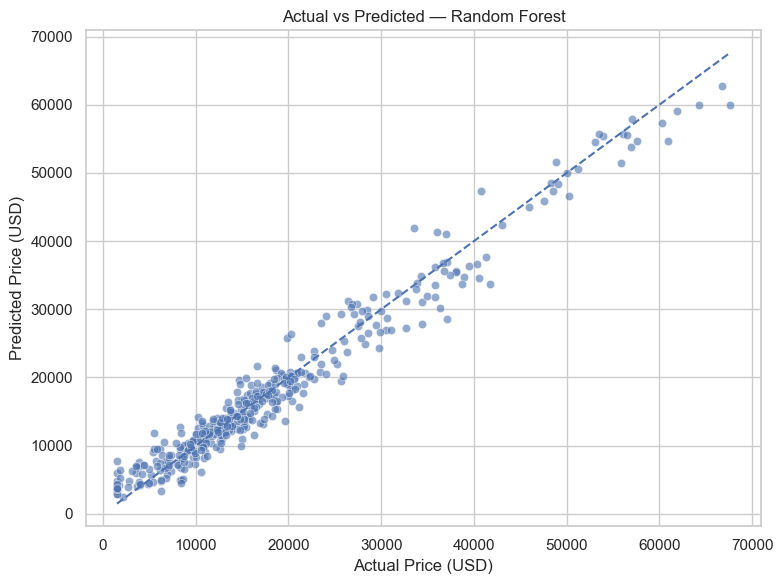

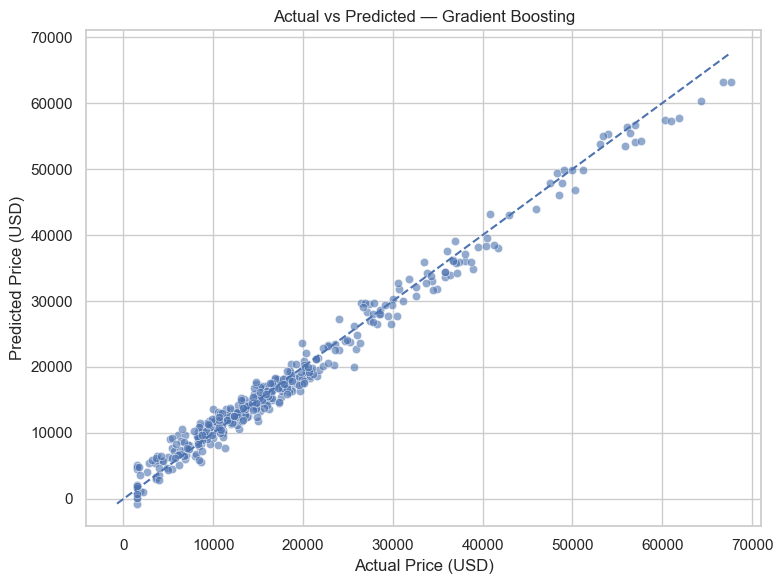

In [92]:
# Graph of ACTUAL VS PREDICTED
for model_name, predictions in model_predictions.items():

    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        x=y_test,
        y=predictions,
        alpha=0.6
    )

    min_value = min(
        y_test.min(),
        predictions.min()
    )

    max_value = max(
        y_test.max(),
        predictions.max()
    )

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    plt.title(
        f"Actual vs Predicted — {model_name}"
    )

    plt.xlabel("Actual Price (USD)")
    plt.ylabel("Predicted Price (USD)")

    plt.tight_layout()
    plt.show()

In [93]:
# FEATURE IMPORTANCE

# For tree models, feature importance is extremely useful.

# First retrieving the transformed feature names:
rf_preprocessor = random_forest_model.named_steps[
    "preprocessor"
]

rf_model = random_forest_model.named_steps[
    "model"
]

feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance.head(20)

,Feature,Importance
6,categorical__Brand_Tier_Luxury,0.35
0,numerical__Car_Age_Years,0.26
8,categorical__Brand_Tier_Premium,0.17
1,numerical__Mileage_KM,0.11
7,categorical__Brand_Tier_Mid-range,0.03
2,numerical__Engine_Size_CC,0.01
13,categorical__City_Market_New York,0.01
10,categorical__City_Market_Karachi,0.01
9,categorical__City_Market_Islamabad,0.01
3,numerical__Horsepower_HP,0.01


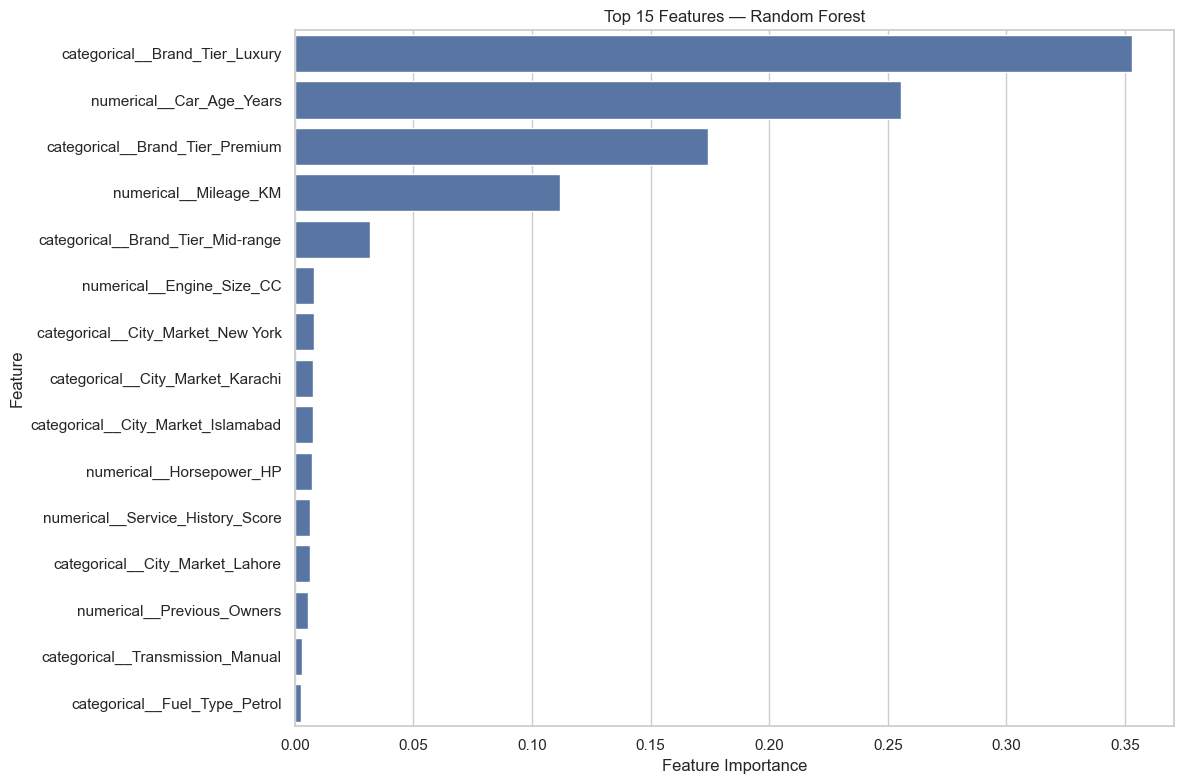

In [94]:
# Visualising the Feature importance
top_features = feature_importance.head(15)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Features — Random Forest"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [95]:
# LINEAR REGRESSION COEFFICIENTS
# This lets you discuss:

# Which features are associated with increases or decreases in predicted price, holding the other model variables constant.

# That's much more academically precise than saying "this feature causes price to increase."
linear_preprocessor = linear_model.named_steps[
    "preprocessor"
]

linear_estimator = linear_model.named_steps[
    "model"
]

linear_feature_names = (
    linear_preprocessor
    .get_feature_names_out()
)

coefficients = pd.DataFrame({
    "Feature": linear_feature_names,
    "Coefficient": linear_estimator.coef_
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficients.head(20)

,Feature,Coefficient,Absolute_Coefficient
6,categorical__Brand_Tier_Luxury,"31,520.33","31,520.33"
8,categorical__Brand_Tier_Premium,"15,552.10","15,552.10"
7,categorical__Brand_Tier_Mid-range,"4,981.23","4,981.23"
10,categorical__City_Market_Karachi,"-4,591.30","4,591.30"
11,categorical__City_Market_Lahore,"-4,478.67","4,478.67"
16,categorical__Fuel_Type_Electric,"4,408.44","4,408.44"
9,categorical__City_Market_Islamabad,"-4,057.02","4,057.02"
1,numerical__Mileage_KM,"-3,804.08","3,804.08"
0,numerical__Car_Age_Years,"-2,364.41","2,364.41"
13,categorical__City_Market_New York,"2,264.97","2,264.97"


In [96]:
# OVERFITTING ANALYSIS
def train_test_performance(model, X_train, y_train, X_test, y_test):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    return {
        "Train_R2": r2_score(y_train, train_pred),
        "Test_R2": r2_score(y_test, test_pred),
        "Train_RMSE": np.sqrt(
            mean_squared_error(y_train, train_pred)
        ),
        "Test_RMSE": np.sqrt(
            mean_squared_error(y_test, test_pred)
        )
    }

In [97]:
# For Random Forest
rf_performance = train_test_performance(
    random_forest_model,
    X_train,
    y_train,
    X_test,
    y_test
)

rf_performance

{'Train_R2': 0.9948603288234094,
 'Test_R2': 0.9627932020400309,
 'Train_RMSE': np.float64(864.1001394928297),
 'Test_RMSE': np.float64(2505.367729695583)}

In [99]:
# Used Car — add training vs testing performance
train_predictions = gradient_boosting_model.predict(X_train)
test_predictions = gradient_boosting_model.predict(X_test)

print("Training R²:",
      r2_score(y_train, train_predictions))

print("Testing R²:",
      r2_score(y_test, test_predictions))

Training R²: 0.9915009787775709
Testing R²: 0.9836283094145961


In [100]:
# cross-validation and hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

grid_search = GridSearchCV(
    gradient_boosting_model,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300}
